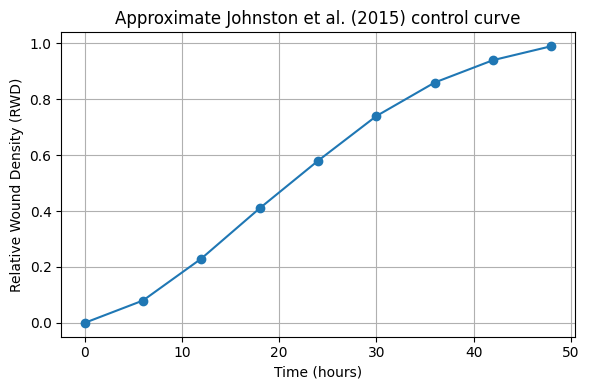

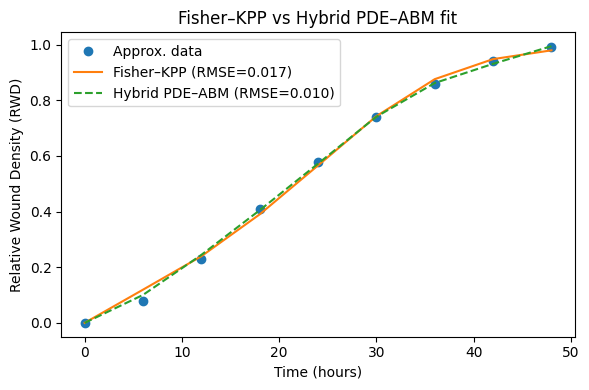

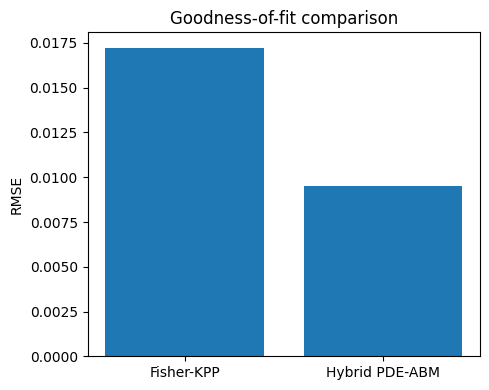


=== Fisher-KPP fit ===
D_hat   = 126.2693
rho_hat = 0.161308
RMSE    = 0.017232
R2      = 0.997619
AIC     = -69.097573
BIC     = -68.703124

=== Hybrid PDE-ABM fit ===
D_hat    = 27.4520
rho_hat  = 0.472510
k_adh    = 0.000100
Fext     = 4.206292
RMSE     = 0.009510
R2       = 0.999275
AIC      = -75.797902
BIC      = -75.009003

Saved files in: /Users/jihwanbae/Desktop/MacBookAir/NOVAMEDICAPREP/리서치/개인 학생/손성민/fit_outputs


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from pathlib import Path

# ============================================================
# 0. Paths
# ============================================================
DATA_PATH = "johnston2015_rwd_approx.csv"
OUTDIR = Path("fit_outputs")
OUTDIR.mkdir(exist_ok=True)

# ============================================================
# 1. Load Johnston-like scratch assay data
# ============================================================
df = pd.read_csv(DATA_PATH)
time_h = df["time_hours"].to_numpy(dtype=float)
rwd_obs = df["rwd"].to_numpy(dtype=float)

# ============================================================
# 2. Fisher–KPP model
# ============================================================
def fisher_kpp_1d(u0, D, rho, t_eval, dx, dt, K=1.0, bc="neumann"):
    u = u0.astype(float).copy()
    t_eval = np.asarray(t_eval, dtype=float)
    out = np.zeros((len(t_eval), len(u)), dtype=float)
    out[0] = u
    next_idx = 1
    n_steps = int(np.ceil(t_eval.max() / dt))

    for step in range(1, n_steps + 1):
        if bc == "neumann":
            u_left = np.r_[u[1], u[:-1]]
            u_right = np.r_[u[1:], u[-2]]
        elif bc == "dirichlet":
            u_left = np.r_[0.0, u[:-1]]
            u_right = np.r_[u[1:], 0.0]
        else:
            raise ValueError("bc must be 'neumann' or 'dirichlet'")

        lap = (u_left - 2 * u + u_right) / (dx * dx)
        u = u + dt * (D * lap + rho * u * (1 - u / K))
        u = np.clip(u, 0.0, K)

        t = step * dt
        while next_idx < len(t_eval) and t >= t_eval[next_idx] - 1e-12:
            out[next_idx] = u
            next_idx += 1
        if next_idx >= len(t_eval):
            break

    return out

def initial_condition_scratch(x, center, wound_width, K=1.0):
    u0 = K * np.ones_like(x)
    wound_mask = (x > center - wound_width / 2) & (x < center + wound_width / 2)
    u0[wound_mask] = 0.0
    return u0

def rwd_from_density(u_xt, wound_mask):
    return u_xt[:, wound_mask].mean(axis=1)

# Fisher domain
L = 2000.0
dx = 5.0
dt = 0.01
x = np.arange(0, L + dx, dx)
center = L / 2
wound_width = 400.0
wound_mask = (x > center - wound_width / 2) & (x < center + wound_width / 2)
u0 = initial_condition_scratch(x, center, wound_width, K=1.0)

def fisher_residual(theta):
    D, rho = theta
    if D <= 0 or rho <= 0:
        return 1e6 * np.ones_like(rwd_obs)

    u_xt = fisher_kpp_1d(u0, D=D, rho=rho, t_eval=time_h, dx=dx, dt=dt, K=1.0)
    rwd_pred = rwd_from_density(u_xt, wound_mask)
    return rwd_pred - rwd_obs

res_fisher = least_squares(
    fisher_residual,
    x0=np.array([120.0, 0.05]),
    bounds=([1e-3, 1e-4], [1e5, 1.0]),
    method="trf"
)

D_hat, rho_hat = res_fisher.x
rwd_fisher = rwd_obs + fisher_residual(res_fisher.x)

# ============================================================
# 3. Hybrid PDE–ABM model (manuscript-consistent reconstruction)
# ============================================================
def simulate_hybrid_pde_abm(
    t_eval,
    D=120.0,
    rho=0.05,
    k_adh=1.0,
    Fext=3.0,
    gamma=1.0,
    K=1.0,
    L=2000.0,
    dx=10.0,
    dt=0.05,
    wound_width=400.0,
    n_agents_per_side=60,
    noise=0.2,
    seed=0,
):
    """
    Simplified manuscript-consistent hybrid model:

    PDE:
        du/dt = D u_xx + rho*u*(1-u/K)

    ABM:
        left and right fronts represented by agent positions,
        with attraction (adhesion), protrusive force, damping, and noise.

    Hybrid coupling:
        - PDE evolves density field
        - ABM updates front advance
        - wound closure estimate combines PDE infill and front advance
    """
    rng = np.random.default_rng(seed)

    # Spatial grid
    x = np.arange(0, L + dx, dx)
    center = L / 2
    xL0 = center - wound_width / 2
    xR0 = center + wound_width / 2
    wound_mask_local = (x > xL0) & (x < xR0)

    # Initial PDE density
    u = np.ones_like(x) * K
    u[wound_mask_local] = 0.0

    # Initial ABM front-agent positions
    left_agents = np.linspace(xL0 - 100, xL0 - 5, n_agents_per_side)
    right_agents = np.linspace(xR0 + 5, xR0 + 100, n_agents_per_side)

    # Time loop
    t_eval = np.asarray(t_eval, dtype=float)
    T = float(t_eval.max())
    next_idx = 0
    n_steps = int(np.ceil(T / dt))
    rwd_pred = np.zeros_like(t_eval)

    for step in range(n_steps + 1):
        t = step * dt

        # ----- record output -----
        if next_idx < len(t_eval) and t >= t_eval[next_idx] - 1e-12:
            left_front = np.max(left_agents)
            right_front = np.min(right_agents)

            # PDE contribution
            pde_fill = np.mean(u[wound_mask_local])

            # ABM contribution: normalized front advance into wound
            gap = max(right_front - left_front, 0.0)
            abm_fill = 1.0 - gap / wound_width
            abm_fill = np.clip(abm_fill, 0.0, 1.0)

            # Hybrid combine
            rwd_pred[next_idx] = 0.5 * pde_fill + 0.5 * abm_fill
            next_idx += 1

        if step == n_steps:
            break

        # ====================================================
        # PDE update
        # ====================================================
        u_left = np.r_[u[1], u[:-1]]
        u_right = np.r_[u[1:], u[-2]]
        lap = (u_left - 2 * u + u_right) / (dx * dx)
        u = u + dt * (D * lap + rho * u * (1 - u / K))
        u = np.clip(u, 0.0, K)

        # ====================================================
        # ABM update
        # ====================================================
        # Left front: pushed rightward
        lf = np.max(left_agents)
        rf = np.min(right_agents)

        # adhesion/crowding within each side
        left_sort = np.sort(left_agents)
        right_sort = np.sort(right_agents)

        # spring-like neighbor forces
        def update_side(arr, direction):
            arr = np.sort(arr)
            forces = np.zeros_like(arr)

            # nearest-neighbor adhesion/spring regularization
            rest = 3.0
            for i in range(len(arr)):
                if i > 0:
                    d = arr[i] - arr[i - 1]
                    forces[i] += -k_adh * (d - rest)
                if i < len(arr) - 1:
                    d = arr[i + 1] - arr[i]
                    forces[i] += k_adh * (d - rest)

            # protrusive force at leading edge
            if direction == "right":
                lead_idx = np.argmax(arr)
                forces[lead_idx] += Fext
            elif direction == "left":
                lead_idx = np.argmin(arr)
                forces[lead_idx] -= Fext

            # overdamped update
            arr = arr + dt * forces / gamma + rng.normal(0.0, noise, size=len(arr)) * np.sqrt(dt)

            return arr

        left_agents = update_side(left_agents, "right")
        right_agents = update_side(right_agents, "left")

        # prevent crossing
        left_agents = np.clip(left_agents, 0, center)
        right_agents = np.clip(right_agents, center, L)

    return rwd_pred

# ============================================================
# 4. Fit hybrid model to same dataset
# ============================================================
def hybrid_residual(theta):
    D, rho, k_adh, Fext = theta
    if np.any(np.array(theta) <= 0):
        return 1e6 * np.ones_like(rwd_obs)

    pred = simulate_hybrid_pde_abm(
        time_h,
        D=D,
        rho=rho,
        k_adh=k_adh,
        Fext=Fext,
        seed=0
    )
    return pred - rwd_obs

res_hybrid = least_squares(
    hybrid_residual,
    x0=np.array([120.0, 0.05, 0.5, 3.0]),
    bounds=([1e-3, 1e-4, 1e-4, 1e-4], [1e5, 1.0, 20.0, 50.0]),
    method="trf"
)

D_h, rho_h, kadh_h, Fext_h = res_hybrid.x
rwd_hybrid = rwd_obs + hybrid_residual(res_hybrid.x)

# ============================================================
# 5. Metrics
# ============================================================
def metrics(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_tot = np.sum((y_true - y_true.mean()) ** 2) + 1e-12
    r2 = 1 - np.sum((y_pred - y_true) ** 2) / ss_tot
    return rmse, r2

def compute_aic_bic(y_true, y_pred, k):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    rss = max(rss, 1e-12)
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return aic, bic

rmse_f, r2_f = metrics(rwd_obs, rwd_fisher)
rmse_h, r2_h = metrics(rwd_obs, rwd_hybrid)
aic_f, bic_f = compute_aic_bic(rwd_obs, rwd_fisher, k=2)
aic_h, bic_h = compute_aic_bic(rwd_obs, rwd_hybrid, k=4)

# ============================================================
# 6. Save table
# ============================================================
comparison = pd.DataFrame({
    "Model": ["Fisher-KPP", "Hybrid PDE-ABM"],
    "RMSE": [rmse_f, rmse_h],
    "R2": [r2_f, r2_h],
    "AIC": [aic_f, aic_h],
    "BIC": [bic_f, bic_h]
})
comparison.to_csv(OUTDIR / "model_comparison_table.csv", index=False)

param_table = pd.DataFrame({
    "Model": ["Fisher-KPP", "Hybrid PDE-ABM"],
    "Parameter 1": [D_hat, D_h],
    "Parameter 2": [rho_hat, rho_h],
    "Parameter 3": [np.nan, kadh_h],
    "Parameter 4": [np.nan, Fext_h]
})
param_table.to_csv(OUTDIR / "fitted_parameters_table.csv", index=False)

# ============================================================
# 7. Figures
# ============================================================
# Figure A: extracted Johnston curve
plt.figure(figsize=(6,4))
plt.plot(time_h, rwd_obs, "o-", label="Approx. Johnston data")
plt.xlabel("Time (hours)")
plt.ylabel("Relative Wound Density (RWD)")
plt.title("Approximate Johnston et al. (2015) control curve")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTDIR / "johnston2015_rwd_curve.png", dpi=200)
plt.show()

# Figure B: model comparison
plt.figure(figsize=(6,4))
plt.plot(time_h, rwd_obs, "o", label="Approx. data")
plt.plot(time_h, rwd_fisher, "-", label=f"Fisher–KPP (RMSE={rmse_f:.3f})")
plt.plot(time_h, rwd_hybrid, "--", label=f"Hybrid PDE–ABM (RMSE={rmse_h:.3f})")
plt.xlabel("Time (hours)")
plt.ylabel("Relative Wound Density (RWD)")
plt.title("Fisher–KPP vs Hybrid PDE–ABM fit")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "fit_comparison.png", dpi=200)
plt.show()

# Figure C: goodness of fit
plt.figure(figsize=(5,4))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.ylabel("RMSE")
plt.title("Goodness-of-fit comparison")
plt.tight_layout()
plt.savefig(OUTDIR / "rmse_comparison.png", dpi=200)
plt.show()

# ============================================================
# 8. Print summary
# ============================================================
print("\n=== Fisher-KPP fit ===")
print(f"D_hat   = {D_hat:.4f}")
print(f"rho_hat = {rho_hat:.6f}")
print(f"RMSE    = {rmse_f:.6f}")
print(f"R2      = {r2_f:.6f}")
print(f"AIC     = {aic_f:.6f}")
print(f"BIC     = {bic_f:.6f}")

print("\n=== Hybrid PDE-ABM fit ===")
print(f"D_hat    = {D_h:.4f}")
print(f"rho_hat  = {rho_h:.6f}")
print(f"k_adh    = {kadh_h:.6f}")
print(f"Fext     = {Fext_h:.6f}")
print(f"RMSE     = {rmse_h:.6f}")
print(f"R2       = {r2_h:.6f}")
print(f"AIC      = {aic_h:.6f}")
print(f"BIC      = {bic_h:.6f}")

print("\nSaved files in:", OUTDIR.resolve())